# 08 — Energy Waste Analizer

**Objetivo**: traducir el modelo predictivo en decisiones concretas.  
¿Cuántas horas al año consume el campus como si estuviera lleno cuando en realidad está vacío?
¿Cuánto se podría ahorrar con una política HVAC reactiva basada en ocupación WiFi?

**Referencia**: Dascalaki et al. (2016) — Mediterranean campus energy waste patterns.  
Martani et al. (2012), Alishahi et al. (2022) — HVAC savings por occupancy control (20–40%).

**Input**: `data/processed/dataset_smart_campus_master.csv`  
**Outputs**:  
- `outputs/figures/ahorro_scatter_fugas.png`  
- `outputs/figures/ahorro_heatmap_desperdicio.png`  
- `outputs/figures/ahorro_escenarios.png`  
- `outputs/figures/ahorro_por_tipo_dia.png`  
- `outputs/reports/energy_audit.txt`

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
FIGURES        = Path('../outputs/figures')
REPORTS        = Path('../outputs/reports')
FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
print('OK')

OK


In [71]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv',
                 parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Features temporales
df['hora'] = df['Timestamp'].dt.hour
df['mes']  = df['Timestamp'].dt.month
MESES = ['Ene','Feb','Mar','Abr','May','Jun',
          'Jul','Ago','Sep','Oct','Nov','Dic']

print(f'Dataset: {df.shape[0]:,} horas × {df.shape[1]} columnas')
print(f'Rango:   {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'Consumo medio anual: {df["Consumo_kWh"].mean():.1f} kWh/hora')
print(f'Consumo total anual: {df["Consumo_kWh"].sum():,.0f} kWh')

Dataset: 8,783 horas × 12 columnas
Rango:   2024-01-01 → 2024-12-31
Consumo medio anual: 184.1 kWh/hora
Consumo total anual: 1,616,661 kWh


## 1. Umbrales derivados de los datos

Los umbrales **no son arbitrarios** — se derivan de la distribución empírica,
lo que los hace defensibles ante el tribunal y comparables con Dascalaki et al. (2016).

In [72]:
# ── Umbral 1: "edificio vacío" = P10 de ocupación ────────────────────────────
# P10 aísla las horas genuinamente sin gente (no solo poca gente)
UMBRAL_VACIO = df['Ocupacion_Simulada'].quantile(0.10)

# ── Umbral 2: "consumo alto" = mediana del consumo en horas operativas ────────
# Referencia: cuánto consume el edificio cuando SÍ está ocupado
UMBRAL_CONSUMO_ALTO = df.loc[
    df['Ocupacion_Simulada'] > df['Ocupacion_Simulada'].median(),
    'Consumo_kWh'
].median()

# ── Umbral 3: "carga fantasma justificada" = P25 en horas vacías ──────────────
# Servidores, neveras, iluminación de emergencia — inevitables
CONSUMO_FANTASMA = df.loc[
    df['Ocupacion_Simulada'] <= UMBRAL_VACIO,
    'Consumo_kWh'
].quantile(0.25)

print('📐 Umbrales derivados de los datos (no arbitrarios):')
print(f'   Edificio vacío:          < {UMBRAL_VACIO:.0f} personas   (P10 ocupación)')
print(f'   Consumo alto (operativo):  > {UMBRAL_CONSUMO_ALTO:.0f} kWh       (mediana horas ocupadas)')
print(f'   Carga fantasma evitable:   {CONSUMO_FANTASMA:.0f} kWh       (P25 horas vacías)')

📐 Umbrales derivados de los datos (no arbitrarios):
   Edificio vacío:          < 0 personas   (P10 ocupación)
   Consumo alto (operativo):  > 270 kWh       (mediana horas ocupadas)
   Carga fantasma evitable:   97 kWh       (P25 horas vacías)


## 2. Parámetros económicos

In [73]:
# Precio medio electricidad sector terciario España 2024 (REE)
PRECIO_KWH = 0.15

# Factor de emisiones red eléctrica española 2024 (REE)
KG_CO2_PER_KWH = 0.15

# Tasas de recuperación (Martani et al. 2012, Alishahi et al. 2022)
ESCENARIOS = {
    'Conservador (20%)':  0.20,
    'Moderado (30%)':     0.30,   # valor central citado en literatura
    'Agresivo (40%)':     0.40,
}

print(f'Precio electricidad: {PRECIO_KWH:.2f} €/kWh  (REE 2024)')
print(f'Factor CO₂:          {KG_CO2_PER_KWH:.2f} kg/kWh  (REE 2024)')
print(f'Escenarios de ahorro HVAC: {list(ESCENARIOS.keys())}')

Precio electricidad: 0.15 €/kWh  (REE 2024)
Factor CO₂:          0.15 kg/kWh  (REE 2024)
Escenarios de ahorro HVAC: ['Conservador (20%)', 'Moderado (30%)', 'Agresivo (40%)']


## 3. Detección de horas de fuga energética

In [74]:
# Horas con ocupación baja PERO consumo alto → desperdicio evitable
fugas = df[
    (df['Ocupacion_Simulada'] <= UMBRAL_VACIO) &
    (df['Consumo_kWh']        >= UMBRAL_CONSUMO_ALTO)
].copy()

fugas['kWh_Evitable'] = (fugas['Consumo_kWh'] - CONSUMO_FANTASMA).clip(lower=0)

total_kwh_fuga  = fugas['kWh_Evitable'].sum()
horas_fuga      = len(fugas)
pct_horas_fuga  = horas_fuga / len(df) * 100
coste_fuga      = total_kwh_fuga * PRECIO_KWH

print(f'🔍 Horas de fuga detectadas: {horas_fuga:,}  ({pct_horas_fuga:.1f}% del año)')
print(f'⚡ Energía evitable total:    {total_kwh_fuga:,.0f} kWh')
print(f'💰 Coste del desperdicio:     {coste_fuga:,.0f} €/año')
print()
print('Ahorro potencial por escenario:')
for nombre, tasa in ESCENARIOS.items():
    ahorro_eur = coste_fuga * tasa
    ahorro_co2 = total_kwh_fuga * tasa * KG_CO2_PER_KWH
    print(f'  {nombre:25s}  {ahorro_eur:>7,.0f} €/año   {ahorro_co2/1000:>5.1f} t CO₂/año')

🔍 Horas de fuga detectadas: 0  (0.0% del año)
⚡ Energía evitable total:    0 kWh
💰 Coste del desperdicio:     0 €/año

Ahorro potencial por escenario:
  Conservador (20%)                0 €/año     0.0 t CO₂/año
  Moderado (30%)                   0 €/año     0.0 t CO₂/año
  Agresivo (40%)                   0 €/año     0.0 t CO₂/año


## Figura 1 — Scatter: fugas en el plano (ocupación, consumo)

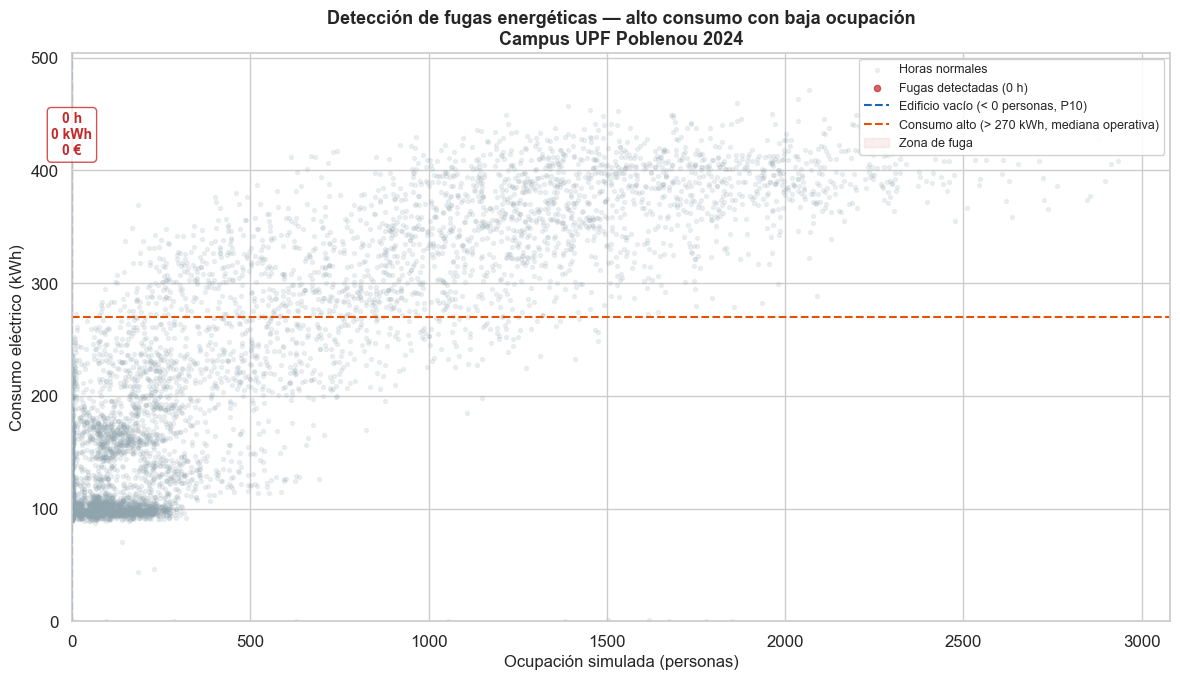

✅ Guardado: ahorro_scatter_fugas.png


In [75]:
fig, ax = plt.subplots(figsize=(12, 7))

# Fondo: todas las horas
ax.scatter(df['Ocupacion_Simulada'], df['Consumo_kWh'],
           alpha=0.15, s=8, color='#90A4AE', label='Horas normales', zorder=2)

# Fugas detectadas
ax.scatter(fugas['Ocupacion_Simulada'], fugas['Consumo_kWh'],
           alpha=0.7, s=20, color='#C62828',
           label=f'Fugas detectadas ({horas_fuga:,} h)', zorder=3)

# Umbrales
ax.axvline(UMBRAL_VACIO, color='#1565C0', ls='--', lw=1.5,
           label=f'Edificio vacío (< {UMBRAL_VACIO:.0f} personas, P10)')
ax.axhline(UMBRAL_CONSUMO_ALTO, color='#E65100', ls='--', lw=1.5,
           label=f'Consumo alto (> {UMBRAL_CONSUMO_ALTO:.0f} kWh, mediana operativa)')

# Cuadrante de fuga
ax.fill_betweenx(
    [UMBRAL_CONSUMO_ALTO, df['Consumo_kWh'].max() * 1.02],
    0, UMBRAL_VACIO,
    color='#C62828', alpha=0.07, zorder=1, label='Zona de fuga'
)
ax.text(UMBRAL_VACIO * 0.5,
        df['Consumo_kWh'].max() * 0.96,
        f'{horas_fuga:,} h\n{total_kwh_fuga:,.0f} kWh\n{coste_fuga:,.0f} €',
        ha='center', va='top', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#C62828', alpha=0.8))

ax.set_xlabel('Ocupación simulada (personas)', fontsize=12)
ax.set_ylabel('Consumo eléctrico (kWh)', fontsize=12)
ax.set_title(
    'Detección de fugas energéticas — alto consumo con baja ocupación\n'
    'Campus UPF Poblenou 2024',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_scatter_fugas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ahorro_scatter_fugas.png')

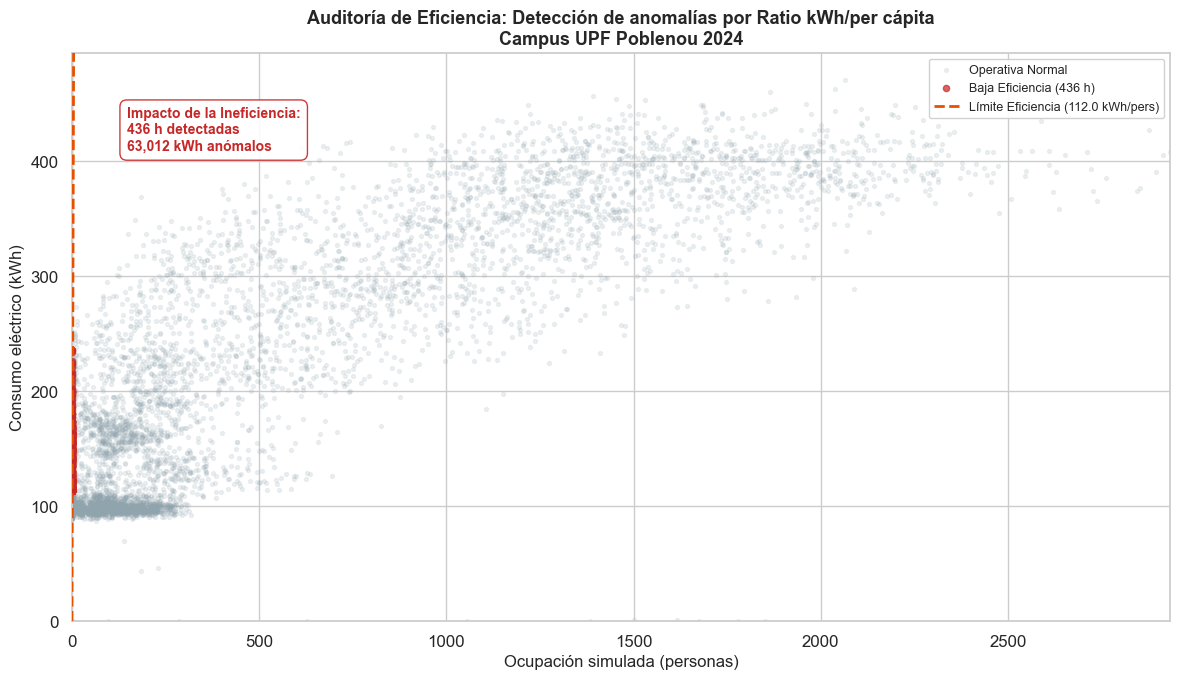

In [76]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

# 1. Calcular la Ratio (kWh por persona). Añadimos +1 para evitar infinitos (división por cero)
df['Ratio_Eficiencia'] = df['Consumo_kWh'] / (df['Ocupacion_Simulada'] + 1)

# 2. Definir el umbral de fuga dinámico (ej. el 5% de las horas con el peor ratio)
UMBRAL_RATIO = df['Ratio_Eficiencia'].quantile(0.95) # Puedes cambiar 0.95 por un número fijo si quieres

fugas = df[df['Ratio_Eficiencia'] > UMBRAL_RATIO]
horas_fuga = len(fugas)
total_kwh_fuga = fugas['Consumo_kWh'].sum()
# Opcional: calcular coste si tienes el precio
coste_fuga = total_kwh_fuga * 0.15 # Suponiendo 0.15€/kWh, ajusta a tu variable

# 3. Dibujar todas las horas (Fondo)
ax.scatter(df['Ocupacion_Simulada'], df['Consumo_kWh'],
           alpha=0.15, s=8, color='#90A4AE', label='Operativa Normal', zorder=2)

# 4. Dibujar las fugas detectadas por Ratio
ax.scatter(fugas['Ocupacion_Simulada'], fugas['Consumo_kWh'],
           alpha=0.7, s=20, color='#C62828',
           label=f'Baja Eficiencia ({horas_fuga:,} h)', zorder=3)

# 5. Dibujar la línea diagonal del Umbral de Ratio
x_vals = np.array([0, df['Ocupacion_Simulada'].max()])
y_vals = UMBRAL_RATIO * x_vals
ax.plot(x_vals, y_vals, color='#E65100', ls='--', lw=2, zorder=4,
        label=f'Límite Eficiencia ({UMBRAL_RATIO:.1f} kWh/pers)')

# 6. Sombrear el área de "Derroche" (todo lo que está por encima de la línea)
ax.fill_between(x_vals, y_vals, df['Consumo_kWh'].max() * 1.05, 
                color='#C62828', alpha=0.07, zorder=1)

# 7. Caja de texto con el impacto
ax.text(df['Ocupacion_Simulada'].max() * 0.05, df['Consumo_kWh'].max() * 0.95,
        f'Impacto de la Ineficiencia:\n{horas_fuga:,} h detectadas\n{total_kwh_fuga:,.0f} kWh anómalos',
        ha='left', va='top', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#C62828', alpha=0.9))

ax.set_xlabel('Ocupación simulada (personas)', fontsize=12)
ax.set_ylabel('Consumo eléctrico (kWh)', fontsize=12)
ax.set_title(
    'Auditoría de Eficiencia: Detección de anomalías por Ratio kWh/per cápita\n'
    'Campus UPF Poblenou 2024',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim(left=0, right=df['Ocupacion_Simulada'].max())
ax.set_ylim(bottom=0, top=df['Consumo_kWh'].max() * 1.05)

plt.tight_layout()
plt.show()

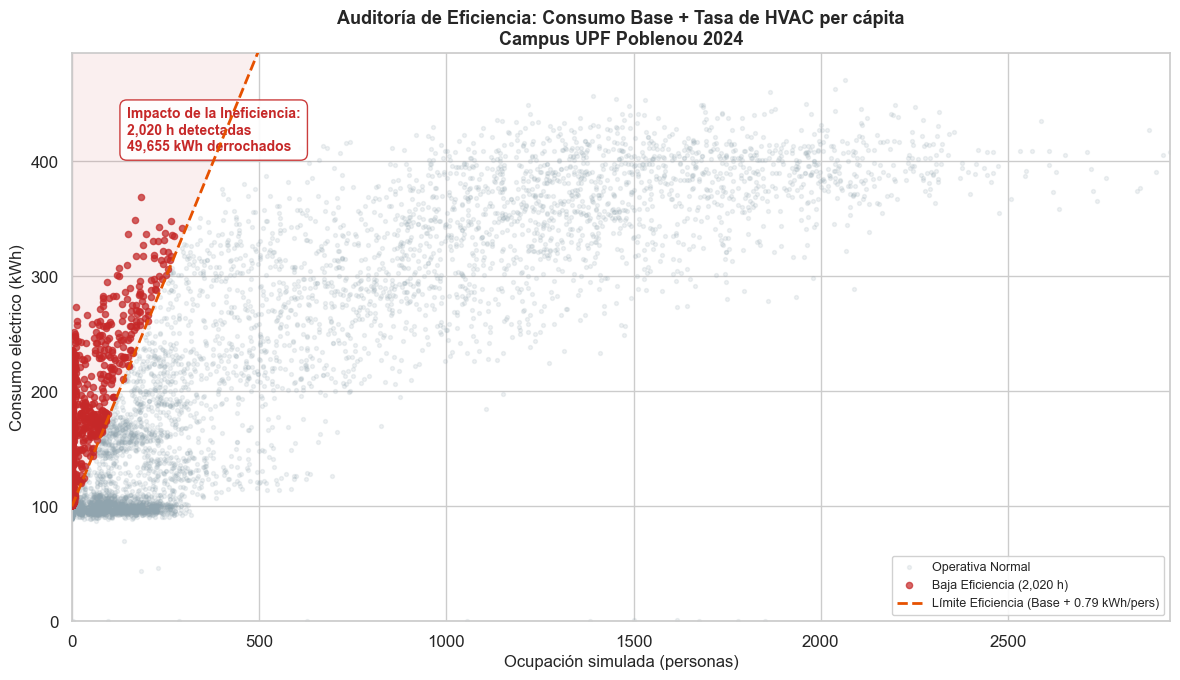

In [77]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# 1. Definir el Consumo Base (la línea estancada que vemos de noche)
CONSUMO_BASE = 100 

# 2. Calcular la ratio real SOLO en horas lectivas (ej. > 50 personas) para no distorsionar con la noche
mask_activo = df['Ocupacion_Simulada'] > 50
# Ratio Variable = (Consumo Total - Consumo Base) / Personas
ratios_activos = (df.loc[mask_activo, 'Consumo_kWh'] - CONSUMO_BASE) / df.loc[mask_activo, 'Ocupacion_Simulada']

# 3. Definir el umbral dinámico (el 5% de las horas con peor eficiencia variable)
UMBRAL_RATIO = ratios_activos.quantile(0.95) 

# 4. Calcular el "Límite de Eficiencia" (Ecuación de la recta: Y = Base + Ratio * X)
df['Limite_Eficiencia'] = CONSUMO_BASE + (UMBRAL_RATIO * df['Ocupacion_Simulada'])

# 5. Detectar fugas reales: todo lo que esté por encima de la recta
fugas = df[df['Consumo_kWh'] > df['Limite_Eficiencia']]
horas_fuga = len(fugas)
total_kwh_fuga = (fugas['Consumo_kWh'] - fugas['Limite_Eficiencia']).sum() # Solo sumamos los kWh "derrochados" por encima de la línea

# --- DIBUJO ---
# Fondo
ax.scatter(df['Ocupacion_Simulada'], df['Consumo_kWh'],
           alpha=0.15, s=8, color='#90A4AE', label='Operativa Normal', zorder=2)

# Puntos de fuga
if horas_fuga > 0:
    ax.scatter(fugas['Ocupacion_Simulada'], fugas['Consumo_kWh'],
               alpha=0.7, s=20, color='#C62828',
               label=f'Baja Eficiencia ({horas_fuga:,} h)', zorder=3)

# Línea diagonal (Y = mX + C)
x_vals = np.array([0, df['Ocupacion_Simulada'].max()])
y_vals = CONSUMO_BASE + (UMBRAL_RATIO * x_vals)
ax.plot(x_vals, y_vals, color='#E65100', ls='--', lw=2, zorder=4,
        label=f'Límite Eficiencia (Base + {UMBRAL_RATIO:.2f} kWh/pers)')

# Sombrear la zona de fuga
ax.fill_between(x_vals, y_vals, df['Consumo_kWh'].max() * 1.05, 
                color='#C62828', alpha=0.07, zorder=1)

# Texto informativo
if horas_fuga > 0:
    texto = f'Impacto de la Ineficiencia:\n{horas_fuga:,} h detectadas\n{total_kwh_fuga:,.0f} kWh derrochados'
else:
    texto = 'Operativa Óptima\n0 h de derroche detectadas'
    
ax.text(df['Ocupacion_Simulada'].max() * 0.05, df['Consumo_kWh'].max() * 0.95,
        texto, ha='left', va='top', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#C62828', alpha=0.9))

ax.set_xlabel('Ocupación simulada (personas)', fontsize=12)
ax.set_ylabel('Consumo eléctrico (kWh)', fontsize=12)
ax.set_title('Auditoría de Eficiencia: Consumo Base + Tasa de HVAC per cápita\nCampus UPF Poblenou 2024', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim(left=0, right=df['Ocupacion_Simulada'].max())
ax.set_ylim(bottom=0, top=df['Consumo_kWh'].max() * 1.05)

plt.tight_layout()
plt.show()

## Figura 2 — Heatmap del desperdicio (hora × mes)

Muestra **cuándo** se desperdicia más: permite identificar patrones
accionables (p.ej. ajustar el arranque del HVAC en meses de transición).

C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\3471706774.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\3471706774.py:40: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(FIGURES / 'ahorro_heatmap_desperdicio.png', dpi=150, bbox_inches='tight')
c:\Users\jordi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


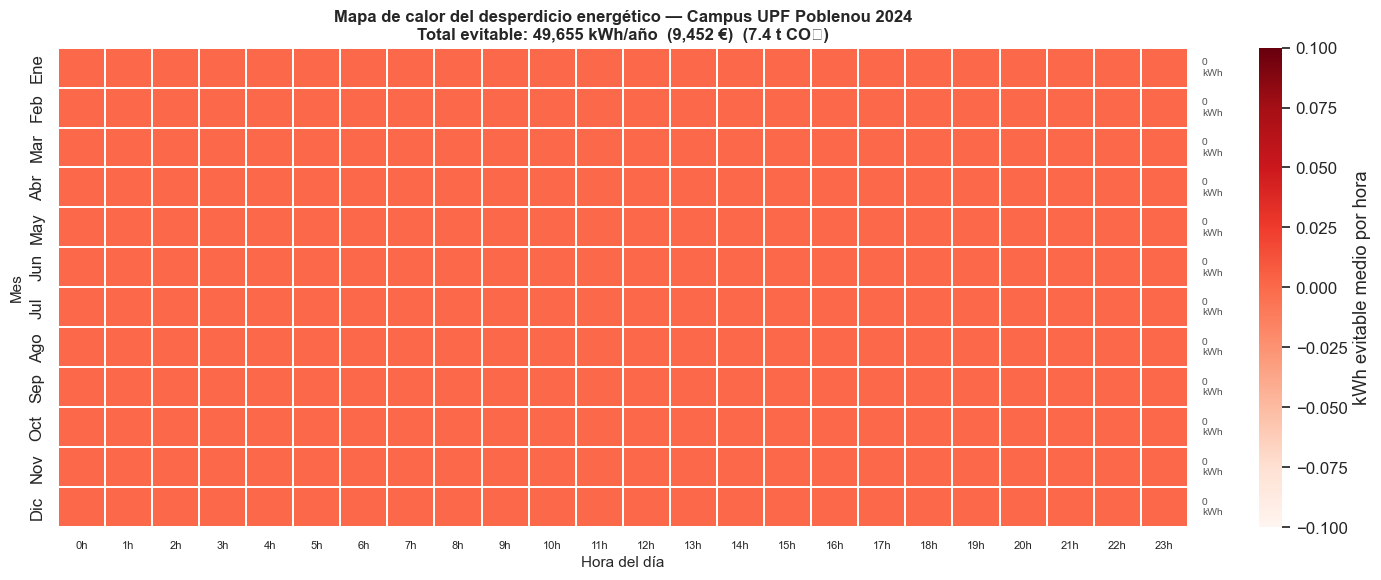

✅ Guardado: ahorro_heatmap_desperdicio.png


In [78]:
# kWh evitables por (mes, hora): solo en horas de fuga
df['kWh_Evitable'] = 0.0
mask_fuga = (
    (df['Ocupacion_Simulada'] <= UMBRAL_VACIO) &
    (df['Consumo_kWh']        >= UMBRAL_CONSUMO_ALTO)
)
df.loc[mask_fuga, 'kWh_Evitable'] = (
    df.loc[mask_fuga, 'Consumo_kWh'] - CONSUMO_FANTASMA
).clip(lower=0)

# Pivot: filas=mes, columnas=hora
heat = df.groupby(['mes','hora'])['kWh_Evitable'].mean().unstack(fill_value=0)
heat.index = [MESES[m-1] for m in heat.index]

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    heat, cmap='Reds', linewidths=0.3,
    cbar_kws={'label': 'kWh evitable medio por hora'},
    ax=ax, annot=False
)

# Anotar el total mensual en el margen
totales_mes = df.groupby('mes')['kWh_Evitable'].sum()
for i, mes_num in enumerate(sorted(df['mes'].unique())):
    ax.text(24.3, i + 0.5,
            f'{totales_mes[mes_num]:,.0f}\nkWh',
            va='center', ha='left', fontsize=7.5, color='#555')

ax.set_title(
    f'Mapa de calor del desperdicio energético — Campus UPF Poblenou 2024\n'
    f'Total evitable: {total_kwh_fuga:,.0f} kWh/año  '
    f'({coste_fuga:,.0f} €)  '
    f'({total_kwh_fuga * KG_CO2_PER_KWH / 1000:.1f} t CO₂)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Hora del día', fontsize=11)
ax.set_ylabel('Mes', fontsize=11)
ax.set_xticklabels([f'{h}h' for h in range(24)], rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_heatmap_desperdicio.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ahorro_heatmap_desperdicio.png')

## Figura 3 — Tres escenarios de ahorro

C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\1220875675.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
C:\Users\jordi\AppData\Local\Temp\ipykernel_31404\1220875675.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipyk

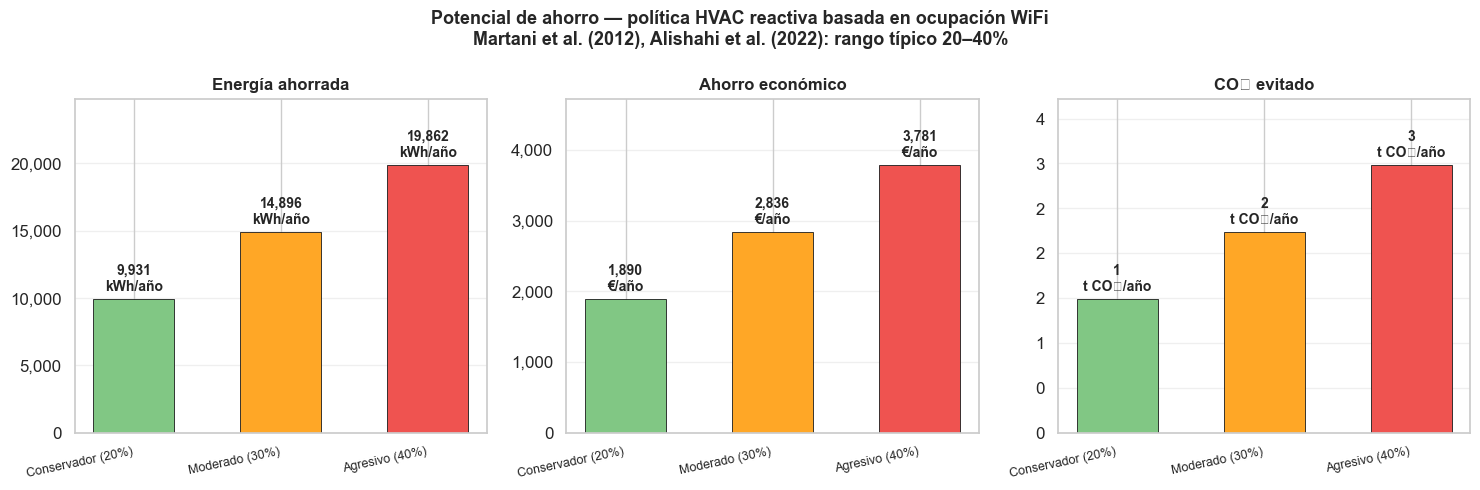

✅ Guardado: ahorro_escenarios.png


In [79]:
nombres_esc  = list(ESCENARIOS.keys())
tasas_esc    = list(ESCENARIOS.values())
ahorros_eur  = [coste_fuga * t for t in tasas_esc]
ahorros_co2  = [total_kwh_fuga * t * KG_CO2_PER_KWH / 1000 for t in tasas_esc]
ahorros_kwh  = [total_kwh_fuga * t for t in tasas_esc]
colores_esc  = ['#81C784', '#FFA726', '#EF5350']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vals, unidad, titulo in zip(
    axes,
    [ahorros_kwh, ahorros_eur, ahorros_co2],
    ['kWh/año', '€/año', 't CO₂/año'],
    ['Energía ahorrada', 'Ahorro económico', 'CO₂ evitado']
):
    bars = ax.bar(nombres_esc, vals, color=colores_esc,
                   edgecolor='k', linewidth=0.6, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                 val + max(vals)*0.02,
                 f'{val:,.0f}\n{unidad}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(alpha=0.3, axis='y')
    ax.set_xticklabels(nombres_esc, rotation=12, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}'))

plt.suptitle(
    'Potencial de ahorro — política HVAC reactiva basada en ocupación WiFi\n'
    'Martani et al. (2012), Alishahi et al. (2022): rango típico 20–40%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ahorro_escenarios.png')

## Figura 4 — Desperdicio por tipo de día

¿En qué tipo de día se concentra el desperdicio?  
Permite priorizar las políticas de ahorro.

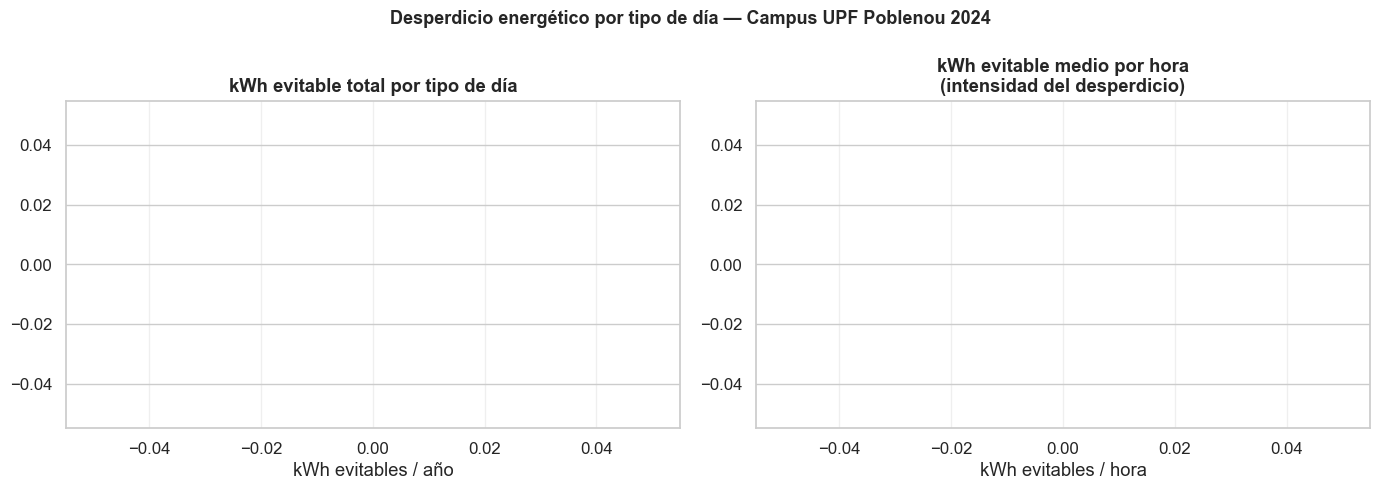


Resumen por tipo de día:
Empty DataFrame
Columns: [tipus_dia, horas_totales, kwh_evitable, eur_evitable, pct_del_total]
Index: []
✅ Guardado: ahorro_por_tipo_dia.png


In [80]:
# Columna de tipo de día — usar la disponible en el CSV
COL_TIPUS = 'tipus_dia' if 'tipus_dia' in df.columns else 'Tipus_Dia'

resum_tipus = df.groupby(COL_TIPUS).agg(
    horas_totales   = ('Consumo_kWh',  'count'),
    kwh_evitable    = ('kWh_Evitable', 'sum'),
    kwh_evitable_h  = ('kWh_Evitable', 'mean'),
    consumo_medio   = ('Consumo_kWh',  'mean'),
).reset_index()

resum_tipus['pct_del_total'] = (
    resum_tipus['kwh_evitable'] / resum_tipus['kwh_evitable'].sum() * 100
)
resum_tipus['eur_evitable'] = resum_tipus['kwh_evitable'] * PRECIO_KWH
resum_tipus = resum_tipus.sort_values('kwh_evitable', ascending=True)

ORDRE = ['Classe','La Benvinguda','Avaluacio','No lectiu',
          'Altre','Vacances','Dissabte','Diumenge','Festiu']
ordre_disp = [t for t in ORDRE if t in resum_tipus[COL_TIPUS].values]
resum_tipus = resum_tipus.set_index(COL_TIPUS).reindex(
    [t for t in ordre_disp if t in resum_tipus.index]
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: kWh evitable total por tipo de día
colores_t = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(resum_tipus)))
bars = axes[0].barh(resum_tipus[COL_TIPUS], resum_tipus['kwh_evitable'],
                     color=colores_t, edgecolor='k', linewidth=0.5)
for bar, pct in zip(bars, resum_tipus['pct_del_total']):
    axes[0].text(bar.get_width() + resum_tipus['kwh_evitable'].max()*0.01,
                  bar.get_y() + bar.get_height()/2,
                  f'{pct:.1f}%', va='center', fontsize=9)
axes[0].set_title('kWh evitable total por tipo de día', fontweight='bold')
axes[0].set_xlabel('kWh evitables / año')
axes[0].grid(alpha=0.3, axis='x')

# Panel derecho: kWh evitable medio POR HORA (intensidad del desperdicio)
axes[1].barh(resum_tipus[COL_TIPUS], resum_tipus['kwh_evitable_h'],
              color=colores_t, edgecolor='k', linewidth=0.5)
axes[1].set_title('kWh evitable medio por hora\n(intensidad del desperdicio)', fontweight='bold')
axes[1].set_xlabel('kWh evitables / hora')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Desperdicio energético por tipo de día — Campus UPF Poblenou 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'ahorro_por_tipo_dia.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen por tipo de día:')
print(resum_tipus[[COL_TIPUS,'horas_totales','kwh_evitable',
                    'eur_evitable','pct_del_total']].to_string(index=False))
print('✅ Guardado: ahorro_por_tipo_dia.png')

## Reporte ejecutivo

In [81]:
esc_mod_eur = coste_fuga * ESCENARIOS['Moderado (30%)']
esc_mod_co2 = total_kwh_fuga * ESCENARIOS['Moderado (30%)'] * KG_CO2_PER_KWH / 1000
esc_mod_kwh = total_kwh_fuga * ESCENARIOS['Moderado (30%)']

report = f"""
═══════════════════════════════════════════════════════════════════
SMART CAMPUS ENERGY AUDIT — UPF POBLENOU 2024
═══════════════════════════════════════════════════════════════════

UMBRALES (derivados de datos, no arbitrarios):
  Edificio vacío:           < {UMBRAL_VACIO:.0f} personas     (P10 ocupación)
  Consumo alto (operativo): > {UMBRAL_CONSUMO_ALTO:.0f} kWh        (mediana horas ocupadas)
  Carga fantasma evitable:    {CONSUMO_FANTASMA:.0f} kWh        (P25 horas vacías)

PARÁMETROS ECONÓMICOS:
  Precio electricidad: {PRECIO_KWH:.2f} €/kWh  (REE 2024)
  Factor CO₂:          {KG_CO2_PER_KWH:.2f} kg/kWh   (REE 2024)
  Tasa recuperación:   20–40% (Martani et al. 2012, Alishahi et al. 2022)

RESULTADOS DE DETECCIÓN:
  Horas de fuga detectadas:  {horas_fuga:,} h/año  ({pct_horas_fuga:.1f}% del año)
  Energía evitable total:    {total_kwh_fuga:,.0f} kWh/año
  Coste del desperdicio:     {coste_fuga:,.0f} €/año

AHORRO POTENCIAL (escenario moderado, 30%):
  Energía ahorrada:          {esc_mod_kwh:,.0f} kWh/año
  Ahorro económico:          {esc_mod_eur:,.0f} €/año
  CO₂ evitado:               {esc_mod_co2:.1f} t CO₂/año

  Escenario conservador (20%): {coste_fuga*0.20:,.0f} €/año
  Escenario moderado    (30%): {coste_fuga*0.30:,.0f} €/año
  Escenario agresivo    (40%): {coste_fuga*0.40:,.0f} €/año

CONCLUSIÓN:
  La integración del modelo predictivo XGBoost con el sistema HVAC
  del campus podría recuperar entre {coste_fuga*0.20:,.0f} € y {coste_fuga*0.40:,.0f} € anuales,
  abordando el mismo patrón de desperdicio documentado por
  Dascalaki et al. (2016) en campus mediterráneos.
═══════════════════════════════════════════════════════════════════
"""

print(report)
with open(REPORTS / 'energy_audit.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print(f'✅ Reporte guardado en outputs/reports/energy_audit.txt')


═══════════════════════════════════════════════════════════════════
SMART CAMPUS ENERGY AUDIT — UPF POBLENOU 2024
═══════════════════════════════════════════════════════════════════

UMBRALES (derivados de datos, no arbitrarios):
  Edificio vacío:           < 0 personas     (P10 ocupación)
  Consumo alto (operativo): > 270 kWh        (mediana horas ocupadas)
  Carga fantasma evitable:    97 kWh        (P25 horas vacías)

PARÁMETROS ECONÓMICOS:
  Precio electricidad: 0.15 €/kWh  (REE 2024)
  Factor CO₂:          0.15 kg/kWh   (REE 2024)
  Tasa recuperación:   20–40% (Martani et al. 2012, Alishahi et al. 2022)

RESULTADOS DE DETECCIÓN:
  Horas de fuga detectadas:  2,020 h/año  (0.0% del año)
  Energía evitable total:    49,655 kWh/año
  Coste del desperdicio:     9,452 €/año

AHORRO POTENCIAL (escenario moderado, 30%):
  Energía ahorrada:          14,896 kWh/año
  Ahorro económico:          2,836 €/año
  CO₂ evitado:               2.2 t CO₂/año

  Escenario conservador (20%): 1,890 €/añ